# Module 2 — Narrative NLP Quality Scoring

This notebook implements **Module 2** of the STR completeness scoring system.

Module 2 asks:

> Does the STR narrative contain enough concrete information for an analyst to understand why the transaction was suspicious?

Instead of only checking narrative length, this scorer checks for analytical signals such as:

- monetary amounts
- transaction dates or date ranges
- customer/account-holder identification
- counterparties or fund-flow direction
- transaction count/type
- risk typology/red-flag pattern
- KYC/profile comparison
- customer explanation/response
- account/reference traceability

The output is a **0 to 1 narrative score** plus a **gap explanation** for every STR.

In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = "xml_output.csv"
OUTPUT_CSV = "module2_narrative_nlp_scores.csv"

df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Narrative column exists:", "report_reason" in df.columns)

df[["report_report_id", "report_reason"]].head()

Rows: 276
Columns: 501
Narrative column exists: True


,report_report_id,report_reason
0,RPT-2026-000001,Suspicious transaction observed.
1,RPT-2026-000002,During the branch's periodic transaction-monit...
2,RPT-2026-000003,During the branch's periodic transaction-monit...
3,RPT-2026-000004,During the branch's periodic transaction-monit...
4,RPT-2026-000005,Suspicious transaction observed.


## 1. Why these Module 2 weights?

Module 2 is about **narrative usefulness**, not whether the transaction is suspicious.

Higher weight is given to signals that directly help an analyst answer:

- What happened?
- Who was involved?
- When did it happen?
- How much money moved?
- Why was the behavior suspicious?
- Is the activity inconsistent with KYC/profile?
- Did the reporting officer record the customer's explanation?

The implementation plan gives Module 2 the largest share of the final score because the narrative often determines whether an STR is actionable.

In [4]:
SIGNAL_WEIGHTS = {
    "length_ok": 0.10,
    "has_amount": 0.15,
    "has_date": 0.12,
    "has_party": 0.15,
    "has_counterparty": 0.10,
    "has_tx_count_or_type": 0.10,
    "has_risk_typology": 0.12,
    "has_kyc_profile_context": 0.10,
    "has_customer_explanation": 0.04,
    "has_account_or_reference": 0.02,
}

weights_df = (
    pd.DataFrame(
        [{"signal": k, "weight": v, "percent": f"{v*100:.0f}%"} for k, v in SIGNAL_WEIGHTS.items()]
    )
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

display(weights_df)
print("Total weight:", round(sum(SIGNAL_WEIGHTS.values()), 4))

,signal,weight,percent
0,has_amount,0.15,15%
1,has_party,0.15,15%
2,has_risk_typology,0.12,12%
3,has_date,0.12,12%
4,length_ok,0.10,10%
5,has_counterparty,0.10,10%
6,has_tx_count_or_type,0.10,10%
7,has_kyc_profile_context,0.10,10%
8,has_customer_explanation,0.04,4%
9,has_account_or_reference,0.02,2%


Total weight: 1.0


## 2. Narrative extraction rules

This version uses robust regular expressions so the notebook works without requiring a heavy NLP install.

In a production version, this can be extended with `spaCy` named entity recognition for PERSON, ORG, DATE, and MONEY entities.

In [5]:
AMOUNT_RE = re.compile(
    r"\b(?:NPR|Rs\.?|रु)?\s*\d{1,3}(?:,\d{2,3})+(?:\.\d+)?\b|"
    r"\b\d+(?:\.\d+)?\s*(?:NPR|Rs\.?)\b",
    re.IGNORECASE,
)

DATE_RE = re.compile(
    r"\b\d{4}[-/]\d{1,2}[-/]\d{1,2}\b|"
    r"\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b"
)

PARTY_RE = re.compile(
    r"\b(account held by|customer|client|holder|account holder)\b",
    re.IGNORECASE,
)

COUNTERPARTY_RE = re.compile(
    r"\b(counterpart(?:y|ies)|principal counterparties observed were|routed to|"
    r"beneficiar(?:y|ies)|receiver|sender)\b",
    re.IGNORECASE,
)

TX_COUNT_TYPE_RE = re.compile(
    r"\b\d+\s+transaction\(s\)|"
    r"\b(cash withdrawals?|cash deposits?|cross-border wires?|ACH transfers?|card payments?|"
    r"transfers?|deposits?|withdrawals?)\b",
    re.IGNORECASE,
)

RISK_TYPOLOGY_RE = re.compile(
    r"\b(threshold|structuring|layering|fan in|fan out|rapid succession|velocity|"
    r"inconsistent|usual corridor|cross-border|behavioural change|behavioral change|"
    r"cash withdrawal|suspicious pattern|unusual pattern)\b",
    re.IGNORECASE,
)

KYC_PROFILE_RE = re.compile(
    r"\b(KYC|declared income|income profile|profile|adverse media|sanctions|"
    r"customer has been with|relationship|reviewing officer)\b",
    re.IGNORECASE,
)

CUSTOMER_EXPLANATION_RE = re.compile(
    r"\b(customer|client|account holder|holder).{0,80}\b"
    r"(stated|said|explained|claimed|provided|responded|confirmed|denied)\b|"
    r"\b(stated|said|explained|claimed|provided|responded|confirmed|denied).{0,80}\b"
    r"(customer|client|account holder|holder)\b",
    re.IGNORECASE,
)

ACCOUNT_REFERENCE_RE = re.compile(
    r"\b(?:account|acct|a/c|reference|ref|internal ref|txn|transaction no\.?|"
    r"transaction number)\s*[:#-]?\s*[A-Z0-9-]{5,}\b|"
    r"\b\d{8,16}\b",
    re.IGNORECASE,
)

GENERIC_NARRATIVES = {
    "suspicious transaction observed.",
    "suspicious transaction observed",
    "suspicious activity observed.",
    "suspicious activity observed",
}

print("Regex rules loaded.")

Regex rules loaded.


## 3. Scoring functions

The score is a weighted sum of narrative signals.

A vague narrative like **"Suspicious transaction observed."** receives a very low score because it has no amount, date, party details, counterparty, typology, or KYC explanation.

In [6]:
def extract_narrative_signals(text, min_words=80):
    if pd.isna(text):
        text = ""
    text = str(text).strip()
    word_count = len(text.split())
    normalized = re.sub(r"\s+", " ", text.lower()).strip()

    return {
        "word_count": word_count,
        "is_generic_narrative": normalized in GENERIC_NARRATIVES,
        "length_ok": word_count >= min_words,
        "has_amount": bool(AMOUNT_RE.search(text)),
        "has_date": bool(DATE_RE.search(text)),
        "has_party": bool(PARTY_RE.search(text)),
        "has_counterparty": bool(COUNTERPARTY_RE.search(text)),
        "has_tx_count_or_type": bool(TX_COUNT_TYPE_RE.search(text)),
        "has_risk_typology": bool(RISK_TYPOLOGY_RE.search(text)),
        "has_kyc_profile_context": bool(KYC_PROFILE_RE.search(text)),
        "has_customer_explanation": bool(CUSTOMER_EXPLANATION_RE.search(text)),
        "has_account_or_reference": bool(ACCOUNT_REFERENCE_RE.search(text)),
        "amount_mentions": AMOUNT_RE.findall(text),
        "date_mentions": DATE_RE.findall(text),
    }


def explain_narrative_gaps(signals):
    gaps = []

    if signals["is_generic_narrative"]:
        gaps.append("Narrative is generic: it says suspicious transaction observed but gives no analytical explanation.")

    if not signals["length_ok"]:
        gaps.append("Narrative is too short to support meaningful analyst review.")
    if not signals["has_amount"]:
        gaps.append("Narrative does not mention a specific monetary amount.")
    if not signals["has_date"]:
        gaps.append("Narrative does not mention a specific transaction date or date range.")
    if not signals["has_party"]:
        gaps.append("Narrative does not clearly identify the customer/account holder.")
    if not signals["has_counterparty"]:
        gaps.append("Narrative does not identify counterparties or fund-flow direction.")
    if not signals["has_tx_count_or_type"]:
        gaps.append("Narrative does not describe transaction count or transaction type.")
    if not signals["has_risk_typology"]:
        gaps.append("Narrative does not explain the suspicion typology or red-flag pattern.")
    if not signals["has_kyc_profile_context"]:
        gaps.append("Narrative does not compare the activity against KYC/profile context.")
    if not signals["has_customer_explanation"]:
        gaps.append("Narrative does not record the customer's explanation or response.")
    if not signals["has_account_or_reference"]:
        gaps.append("Narrative does not include account/reference numbers for traceability.")

    return gaps if gaps else ["Narrative appears analytically complete."]


def score_narrative(text, min_words=80):
    signals = extract_narrative_signals(text, min_words=min_words)
    score = sum(SIGNAL_WEIGHTS[k] * float(bool(signals[k])) for k in SIGNAL_WEIGHTS)
    return round(score, 4), signals, explain_narrative_gaps(signals)


example_text = df.loc[0, "report_reason"]
score, signals, gaps = score_narrative(example_text)

print("Example narrative:")
print(example_text)
print("\\nScore:", score)
print("\\nSignals:")
display(pd.DataFrame([signals]).drop(columns=["amount_mentions", "date_mentions"]))
print("\\nGaps:")
for gap in gaps:
    print("-", gap)

Example narrative:
Suspicious transaction observed.
\nScore: 0.0
\nSignals:


,word_count,is_generic_narrative,length_ok,has_amount,has_date,has_party,has_counterparty,has_tx_count_or_type,has_risk_typology,has_kyc_profile_context,has_customer_explanation,has_account_or_reference
0,3,True,False,False,False,False,False,False,False,False,False,False


\nGaps:
- Narrative is generic: it says suspicious transaction observed but gives no analytical explanation.
- Narrative is too short to support meaningful analyst review.
- Narrative does not mention a specific monetary amount.
- Narrative does not mention a specific transaction date or date range.
- Narrative does not clearly identify the customer/account holder.
- Narrative does not identify counterparties or fund-flow direction.
- Narrative does not describe transaction count or transaction type.
- Narrative does not explain the suspicion typology or red-flag pattern.
- Narrative does not compare the activity against KYC/profile context.
- Narrative does not record the customer's explanation or response.
- Narrative does not include account/reference numbers for traceability.


## 4. Apply Module 2 to every STR report

In [7]:
scored_rows = []

for _, row in df.iterrows():
    score, signals, gaps = score_narrative(row["report_reason"])

    out = {
        "report_report_id": row.get("report_report_id"),
        "module2_narrative_score": score,
        "narrative_word_count": signals["word_count"],
        "is_generic_narrative": int(signals["is_generic_narrative"]),
        "module2_gaps": " | ".join(gaps),
        "report_reason": row["report_reason"],
    }

    for signal in SIGNAL_WEIGHTS:
        out[signal] = int(bool(signals[signal]))

    out["amount_mentions"] = ", ".join(signals["amount_mentions"])
    out["date_mentions"] = ", ".join(signals["date_mentions"])

    scored_rows.append(out)

module2_df = pd.DataFrame(scored_rows)

def score_band(score):
    if score >= 0.80:
        return "High narrative quality"
    if score >= 0.50:
        return "Medium narrative quality"
    return "Low narrative quality"

module2_df["narrative_quality_band"] = module2_df["module2_narrative_score"].apply(score_band)

display(module2_df.head())

,report_report_id,module2_narrative_score,narrative_word_count,is_generic_narrative,module2_gaps,report_reason,length_ok,has_amount,has_date,has_party,has_counterparty,has_tx_count_or_type,has_risk_typology,has_kyc_profile_context,has_customer_explanation,has_account_or_reference,amount_mentions,date_mentions,narrative_quality_band
0,RPT-2026-000001,0.00,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.,0,0,0,0,0,0,0,0,0,0,,,Low narrative quality
1,RPT-2026-000002,0.94,187,0,Narrative does not record the customer's expla...,During the branch's periodic transaction-monit...,1,1,1,1,1,1,1,1,0,0,"NPR 21,807","2022-10-07, 2022-10-07",High narrative quality
2,RPT-2026-000003,0.94,190,0,Narrative does not record the customer's expla...,During the branch's periodic transaction-monit...,1,1,1,1,1,1,1,1,0,0,"NPR 1,214,020","2022-10-07, 2022-10-07",High narrative quality
3,RPT-2026-000004,0.94,186,0,Narrative does not record the customer's expla...,During the branch's periodic transaction-monit...,1,1,1,1,1,1,1,1,0,0,"NPR 813,936","2022-10-07, 2022-10-07",High narrative quality
4,RPT-2026-000005,0.00,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.,0,0,0,0,0,0,0,0,0,0,,,Low narrative quality


## 5. Module 2 summary

In [8]:
summary = pd.DataFrame({
    "metric": [
        "Total STR reports",
        "Average Module 2 score",
        "Median Module 2 score",
        "Minimum Module 2 score",
        "Maximum Module 2 score",
        "Generic narratives",
        "Detailed narratives",
    ],
    "value": [
        len(module2_df),
        round(module2_df["module2_narrative_score"].mean(), 4),
        round(module2_df["module2_narrative_score"].median(), 4),
        round(module2_df["module2_narrative_score"].min(), 4),
        round(module2_df["module2_narrative_score"].max(), 4),
        int(module2_df["is_generic_narrative"].sum()),
        int((1 - module2_df["is_generic_narrative"]).sum()),
    ]
})

display(summary)

band_counts = module2_df["narrative_quality_band"].value_counts().rename_axis("band").reset_index(name="count")
display(band_counts)

,metric,value
0,Total STR reports,276.0000
1,Average Module 2 score,0.5994
2,Median Module 2 score,0.9400
3,Minimum Module 2 score,0.0000
4,Maximum Module 2 score,0.9400
5,Generic narratives,100.0000
6,Detailed narratives,176.0000


,band,count
0,High narrative quality,176
1,Low narrative quality,100


## 6. Signal coverage

This table shows which narrative signals appear across the dataset.

A strong STR narrative should usually include amount, date, parties, counterparties, typology, and profile context.  
Customer explanation and account/reference traceability are especially useful future improvements.

In [9]:
signal_coverage = []

for signal in SIGNAL_WEIGHTS:
    count = int(module2_df[signal].sum())
    signal_coverage.append({
        "signal": signal,
        "reports_with_signal": count,
        "coverage_percent": round(count / len(module2_df) * 100, 2),
        "weight": SIGNAL_WEIGHTS[signal],
    })

signal_coverage_df = pd.DataFrame(signal_coverage).sort_values("coverage_percent", ascending=False)
display(signal_coverage_df)

,signal,reports_with_signal,coverage_percent,weight
0,length_ok,176,63.77,0.10
1,has_amount,176,63.77,0.15
2,has_date,176,63.77,0.12
3,has_party,176,63.77,0.15
4,has_counterparty,176,63.77,0.10
5,has_tx_count_or_type,176,63.77,0.10
6,has_risk_typology,176,63.77,0.12
7,has_kyc_profile_context,176,63.77,0.10
8,has_customer_explanation,0,0.00,0.04
9,has_account_or_reference,0,0.00,0.02


## 7. Visualizations

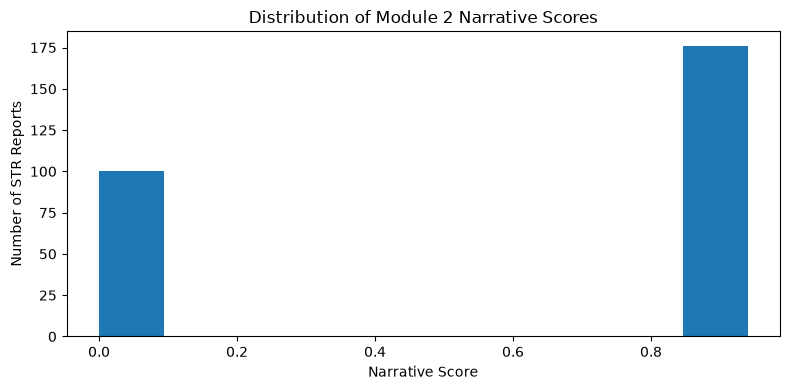

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(module2_df["module2_narrative_score"], bins=10)
plt.title("Distribution of Module 2 Narrative Scores")
plt.xlabel("Narrative Score")
plt.ylabel("Number of STR Reports")
plt.tight_layout()
plt.show()

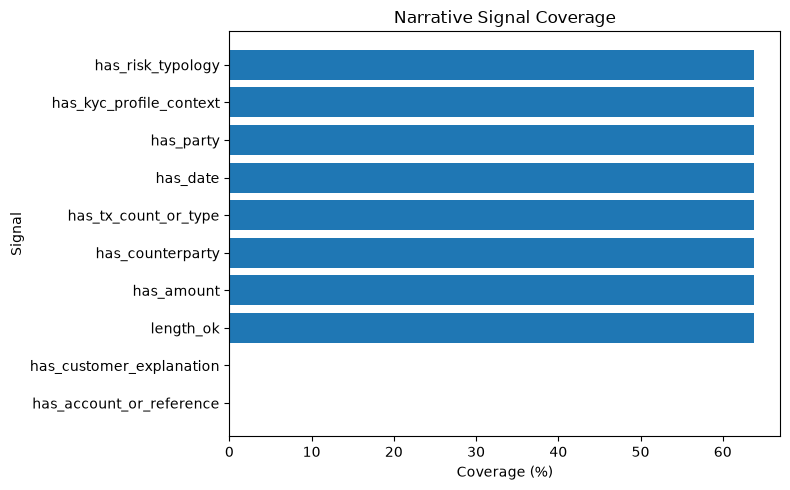

In [11]:
plot_df = signal_coverage_df.sort_values("coverage_percent")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["signal"], plot_df["coverage_percent"])
plt.title("Narrative Signal Coverage")
plt.xlabel("Coverage (%)")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()

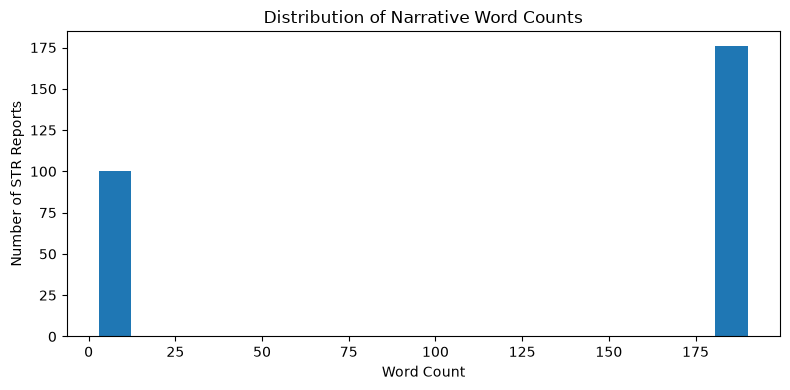

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(module2_df["narrative_word_count"], bins=20)
plt.title("Distribution of Narrative Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Number of STR Reports")
plt.tight_layout()
plt.show()

## 8. Bottom reports: what should the reporting officer fix?

These are the clearest examples for your demo because the gap explainer gives a direct remediation list.

In [13]:
bottom_reports = module2_df.sort_values(
    ["module2_narrative_score", "narrative_word_count"],
    ascending=[True, True]
)[[
    "report_report_id",
    "module2_narrative_score",
    "narrative_word_count",
    "is_generic_narrative",
    "module2_gaps",
    "report_reason",
]].head(10)

display(bottom_reports)

,report_report_id,module2_narrative_score,narrative_word_count,is_generic_narrative,module2_gaps,report_reason
0,RPT-2026-000001,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
4,RPT-2026-000005,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
8,RPT-2026-000009,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
10,RPT-2026-000011,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
12,RPT-2026-000013,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
18,RPT-2026-000019,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
20,RPT-2026-000021,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
21,RPT-2026-000022,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
23,RPT-2026-000024,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.
24,RPT-2026-000025,0.0,3,1,Narrative is generic: it says suspicious trans...,Suspicious transaction observed.


## 9. Top reports: strong narrative examples

These reports contain the core analytical narrative signals: amount, date range, customer/account holder, counterparties, transaction type, risk typology, and KYC/profile context.

In [ ]:
top_reports = module2_df.sort_values(
    ["module2_narrative_score", "narrative_word_count"],
    ascending=[False, False]
)[[
    "report_report_id",
    "module2_narrative_score",
    "narrative_word_count",
    "has_amount",
    "has_date",
    "has_party",
    "has_counterparty",
    "has_risk_typology",
    "has_kyc_profile_context",
    "has_customer_explanation",
    "has_account_or_reference",
    "report_reason",
]].head(10)

display(top_reports)

,report_report_id,module2_narrative_score,narrative_word_count,has_amount,has_date,has_party,has_counterparty,has_risk_typology,has_kyc_profile_context,has_customer_explanation,has_account_or_reference,report_reason
0,RPT-2026-000001,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
4,RPT-2026-000005,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
8,RPT-2026-000009,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
10,RPT-2026-000011,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
12,RPT-2026-000013,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
18,RPT-2026-000019,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
20,RPT-2026-000021,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
21,RPT-2026-000022,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
23,RPT-2026-000024,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.
24,RPT-2026-000025,0.0,3,0,0,0,0,0,0,0,0,Suspicious transaction observed.


## 10. Should-be-included narrative items

Based on this dataset, the narratives are split into two groups:

1. generic narratives with almost no analytical detail
2. detailed narratives that contain amount/date/party/counterparty/typology/profile context

However, even the detailed narratives usually miss two important analyst-facing items:

- the **customer's explanation or response**
- **account/reference numbers inside the narrative** for easier traceability

These should be mentioned in the final gap explainer and future-improvement section.

In [15]:
should_include = pd.DataFrame([
    {
        "missing_item": "Customer explanation / response",
        "why_it_matters": "Shows whether the reporting officer contacted the customer and records the claimed purpose/source of funds.",
        "module2_signal": "has_customer_explanation",
        "current_coverage_percent": signal_coverage_df.loc[
            signal_coverage_df["signal"].eq("has_customer_explanation"), "coverage_percent"
        ].iloc[0],
    },
    {
        "missing_item": "Account or reference numbers in narrative",
        "why_it_matters": "Lets an analyst trace the narrative back to the exact account, transaction reference, or internal case reference.",
        "module2_signal": "has_account_or_reference",
        "current_coverage_percent": signal_coverage_df.loc[
            signal_coverage_df["signal"].eq("has_account_or_reference"), "coverage_percent"
        ].iloc[0],
    },
])

display(should_include)

,missing_item,why_it_matters,module2_signal,current_coverage_percent
0,Customer explanation / response,Shows whether the reporting officer contacted ...,has_customer_explanation,0.0
1,Account or reference numbers in narrative,Lets an analyst trace the narrative back to th...,has_account_or_reference,0.0


## 11. Export Module 2 results

In [16]:
module2_df.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV)
print("Rows exported:", len(module2_df))

Saved: module2_narrative_nlp_scores.csv
Rows exported: 276


## Final interpretation

Module 2 successfully separates weak generic narratives from strong analytical narratives.

The most important finding is:

> STRs with generic narratives should be sent back for remediation because they do not tell the analyst what happened, who was involved, how much money moved, when it happened, or why it was suspicious.

For the detailed STRs, the next improvement is to record the customer explanation and include account/reference traceability inside the narrative.